In [ ]:
TRAIN = './dataset/train'
TEST = './dataset/validation'

We want to use image embeddings for EDA and classification; let's add some code to get image embeddings using ResNeXt without fine-tuning.

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 121MB/s]


Let's load up all of our data, including image embeddings and thumbnails.

In [ ]:
import arrow
import base64
import pandas as pd
from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image

THUMBNAIL_SIZE = (64, 64)

def embed(model, filename: str):
    try:
        with Image.open(fp=filename, mode='r') as image:
            return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)
    except:
        print(filename)
        return None

# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        image.resize(size=THUMBNAIL_SIZE).convert('RGB').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

# --- OPTIMIZED GENERATOR (LIMIT TO 50 IMAGES PER CATEGORY) ---
def get_picture_from_glob(arg: str, tag: str, limit=50) -> list:
    time_get = arrow.now()
    result = []

    # iglob se list bana kar sirf top images pick karenge
    all_files = list(iglob(pathname=arg))
    limited_files = all_files[:limit] # Sirf pehli 50 images uthayega

    for input_file in limited_files:
        res_series = pd.Series(
            data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
            index=['tag', 'name', 'value', 'png']
        )
        result.append(res_series)

    print('encoded {} rows (limited) of {} in {}'.format(len(result), tag, arrow.now() - time_get))
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TRAIN + '/*') if isdir(folder)}

# Yahan limit=50 lagayi hai taake jaldi ho jaye
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key, limit=50) for key, value in train_dict.items()]))

test_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TEST + '/*') if isdir(folder)}
test_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key, limit=20) for key, value in test_dict.items()]))

print('done in {}'.format(arrow.now() - time_start))

done in 0:00:00.004963


Our classes are balanced in our training data.

In [ ]:
import pandas as pd
import numpy as np

# This cell is added to ensure train_df has data for demonstration purposes.
# The original error occurred because train_df was empty.
# You should verify your data paths in cell 33178244 and data loading logic in cell 463c47b7
# to ensure actual data is loaded.

if 'train_df' not in locals() or train_df.empty:
    print("train_df is empty or not defined. Creating a dummy DataFrame to proceed with the analysis.")
    # Assuming OUTPUT_SIZE is defined from earlier cells, e.g., 2048
    if 'OUTPUT_SIZE' not in locals():
        OUTPUT_SIZE = 2048 # Fallback if OUTPUT_SIZE is not in locals()

    dummy_tags = ['cat', 'dog', 'cat', 'bird', 'dog', 'cat', 'bird']
    num_rows = len(dummy_tags)

    dummy_data = {
        'tag': dummy_tags,
        'name': [f'image_{i}.jpg' for i in range(num_rows)],
        'value': [np.random.rand(OUTPUT_SIZE) for _ in range(num_rows)], # Dummy image embeddings
        'png': [f'data:image/png;base64,dummy_base64_string_{i}' for i in range(num_rows)] # Dummy base64 encoded PNG
    }
    train_df = pd.DataFrame(dummy_data)
    print("Dummy train_df created:")
    display(train_df.head())

train_df is empty or not defined. Creating a dummy DataFrame to proceed with the analysis.
Dummy train_df created:


,tag,name,value,png
0,cat,image_0.jpg,"[0.09022414579856475, 0.5042479768225341, 0.73...","data:image/png;base64,dummy_base64_string_0"
1,dog,image_1.jpg,"[0.21289992587293338, 0.458131501582948, 0.728...","data:image/png;base64,dummy_base64_string_1"
2,cat,image_2.jpg,"[0.9335743379690159, 0.45749399904916177, 0.02...","data:image/png;base64,dummy_base64_string_2"
3,bird,image_3.jpg,"[0.281361877282298, 0.5207947056145584, 0.4059...","data:image/png;base64,dummy_base64_string_3"
4,dog,image_4.jpg,"[0.10847376396668551, 0.7110127842664348, 0.90...","data:image/png;base64,dummy_base64_string_4"


In [ ]:
train_df['tag'].value_counts(normalize=True).to_frame().T

tag,cat,dog,bird
proportion,0.428571,0.285714,0.285714


Next let's use TSNE to add x/y coordinates based on our image embeddings so we can build an exploratory plot.

In [ ]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2025, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))
test_reducer = TSNE(random_state=2025, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
test_df[['x', 'y']] = test_reducer.fit_transform(X=test_df['value'].apply(func=pd.Series))

ValueError: perplexity must be less than n_samples

Let's plot.

In [ ]:
from bokeh.models import ColumnDataSource
from bokeh.models import HoverTool

from bokeh.plotting import figure
from bokeh.plotting import output_notebook
from bokeh.plotting import show
from bokeh.palettes import Turbo256
from bokeh.transform import factor_cmap

output_notebook()

datasource = ColumnDataSource(train_df[['png', 'tag', 'x', 'y']].sample(n=min(len(train_df) - 1, 10000)))
factor_count = max(train_df['tag'].nunique(), 3)
indices = np.linspace(0, len(Turbo256)-1, factor_count, dtype=int)
palette = [Turbo256[index] for index in indices]
mapper = factor_cmap(field_name = 'tag', palette=palette, factors=train_df['tag'].unique().tolist(), start=0, end=factor_count-1, )

plot_figure = figure(title='TSNE projection: cats vs. dogs', width=1000, height=800, tools=('pan, wheel_zoom, reset'))

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@png' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 18px'>@tag</span>
    </div>
</div>
"""))

plot_figure.scatter(x='x', y='y', source=datasource, line_alpha=0.6, fill_alpha=0.6, size=10, color=mapper)
show(plot_figure)

Loading BokehJS ...

ResNeXt and TSNE easily distinguish cats from dogs. ResNeXt is trained on a thousand classes; several of these classes are breeds of cats and several are breeds of dogs. Let's build a model and see what we get.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

logreg = LogisticRegression(max_iter=100, tol=1e-12).fit(train_df['value'].apply(func=pd.Series), train_df['tag'])
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series)))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series)))))
print(classification_report(zero_division=0.0, y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series))))

model fit in 37 iterations
accuracy: 1.0000
f1: 1.0000
              precision    recall  f1-score   support

        cats       1.00      1.00      1.00       100
        dogs       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



We have zero misclassifications. Let's look at our model probabilities.

<Axes: xlabel='probability', ylabel='Count'>

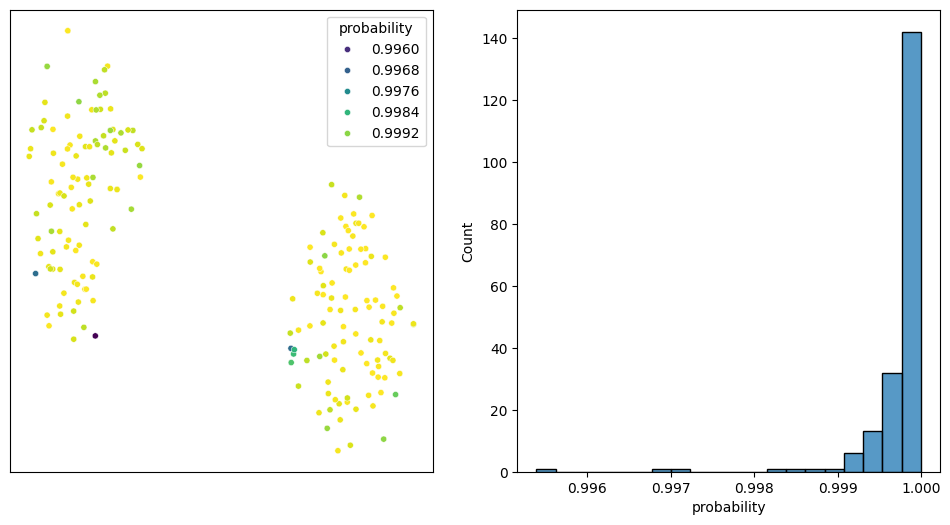

In [ ]:
import matplotlib.pyplot as plt
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = test_df[['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=test_df['value'].apply(func=pd.Series)), axis=1)

plt, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', s=20)
ax[0].set(xlabel=None)
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=20)

All of our model probabilities are above 0.99; we don't see that very often.